In [1]:
import matplotlib.pyplot as plt
import numpy as np

from superfv.tools.variable_index_map import VariableIndexMap
from superfv.configs import generate_fv_scheme_parameters, HydroParameters
from superfv import RiemannSolver
from superfv.mesh import UniformFiniteVolumeMesh
from superfv.finite_volume_driver import update_fv_fluxes
from superfv.bin._finite_volume_driver import update_fv_fluxes as update_fv_fluxes_cpp

p = 2
N = 32
ng = 2
gamma = 1.4
isothermal = False
iso_cs = 1.0

In [2]:
idx = VariableIndexMap(
    {"rho": 0, "vx": 1, "vy": 2, "vz": 3, "P": 4, "mx": 1, "my": 2, "mz": 3, "E": 4},
    group_var_map={
        "v": ["vx", "vy", "vz"],
        "m": ["mx", "my", "mz"],
        "primitives": ["rho", "v", "P"],
        "conservatives": ["rho", "m", "E"],
    },
)

fv_scheme = generate_fv_scheme_parameters("test", p)
hydro_params = HydroParameters(
    gamma=1.4, riemann_solver=RiemannSolver.HLLC, isothermal=isothermal, iso_cs=iso_cs, CFL=0.8
)

mesh = UniformFiniteVolumeMesh(
    (0.0, 1.0),
    (0.0, 1.0),
    (0.0, 1.0),
    N,
    1,
    1,
    ng,
    ("x",),
)

In [3]:
_q_ = np.zeros((idx.nvars, *mesh._shape_))

_q_[idx("rho")] = 1.0
_q_[idx("rho"), mesh._shape_[0] // 4 : 3 * mesh._shape_[0] // 4, 0, 0] = 2.0
_q_[idx("mx")] = 1.5
_q_[idx("E")] = 3.0

_F1_ = np.empty((5, mesh.shape[0] + 1, 1, 1))
F2 = np.empty((5, mesh.shape[0] + 1, 1, 1))

In [4]:
# %%timeit
update_fv_fluxes(
    _q_,
    np.empty_like(_q_),
    _F1_,
    np.array([]),
    np.array([]),
    np.array([]),
    np.array([]),
    np.array([]),
    idx,
    ("x",),
    mesh,
    fv_scheme,
    hydro_params,
    0.0,
)

/Users/jonathan/Desktop/superfv/superfv/hydro.py:172: RuntimeWarning: divide by zero encountered in divide
  vx = mx / rho
/Users/jonathan/Desktop/superfv/superfv/hydro.py:172: RuntimeWarning: invalid value encountered in divide
  vx = mx / rho
/Users/jonathan/Desktop/superfv/superfv/hydro.py:173: RuntimeWarning: divide by zero encountered in divide
  vy = my / rho
/Users/jonathan/Desktop/superfv/superfv/hydro.py:173: RuntimeWarning: invalid value encountered in divide
  vy = my / rho
/Users/jonathan/Desktop/superfv/superfv/hydro.py:174: RuntimeWarning: invalid value encountered in divide
  vz = mz / rho


In [5]:
# %%timeit
update_fv_fluxes_cpp(
    _q_,
    F2,
    np.empty_like(F2),
    np.empty_like(F2),
    fv_scheme.p,
    mesh.nghost,
    hydro_params.gamma,
    hydro_params.isothermal,
    hydro_params.iso_cs,
)

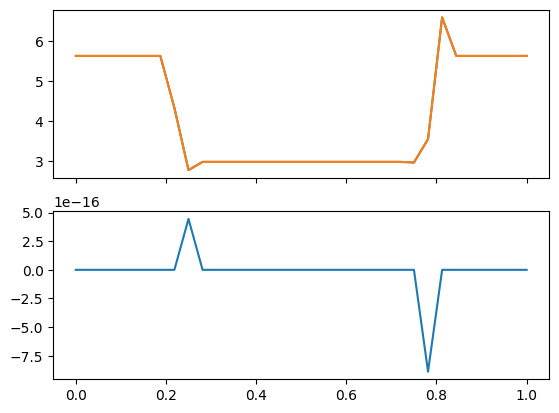

In [6]:
fig, ax = plt.subplots(2, 1, sharex=True)

ax[0].plot(mesh.faces[0], _F1_[4, :, 0, 0])
ax[0].plot(mesh.faces[0], F2[4, :, 0, 0])
ax[1].plot(mesh.faces[0], F2[4, :, 0, 0] - _F1_[4, :, 0, 0])